# Import Modules

In [1]:
import time
import pianno as po
import scanpy as sc
import squidpy as sq
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Step0：Create Pianno Object

In [2]:
data_path = "/home/yqzhou/JUPYTER/MyPackage/pianno1/data/dlPFC-151674/"
count_file = "filtered_feature_bc_matrix.h5"
adata = po.CreatePiannoObject(data_path=data_path, count_file=count_file, min_spots_prop=0.01)

R[write to console]: Loading required package: scran

R[write to console]: Loading required package: SingleCellExperiment

R[write to console]: Loading required package: SummarizedExperiment

R[write to console]: Loading required package: MatrixGenerics

R[write to console]: Loading required package: matrixStats

R[write to console]: 
Attaching package: ‘MatrixGenerics’


R[write to console]: The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, ro

[1] "load scran successfully"


In [3]:
adata

AnnData object with n_obs × n_vars = 3673 × 14711
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'SizeFactor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'RawX'

#### Noise reduction will take a long time.
#### A denoised object which can be loaded directly:
#### adata = sc.read("~/data/dlPFC-151674/adata.h5ad")

In [4]:
start = time.time()
###
adata = po.SAVER(adata, layer_key='DenoisedX')
###
end = time.time()
m, s = divmod((end - start), 60) 
h, m = divmod(m, 60)
print(f"S1 Expected run time: {int(h)} h {int(m)} min {round(s)} s")

R[write to console]: Loading required package: SAVER



[1] "load SAVER successfully"


R[write to console]: 14711 genes, 3673 cells

R[write to console]: Running SAVER with 1 worker(s)

R[write to console]: Calculating predictions for 14711 genes using 8152 genes and 3673 cells...

R[write to console]: Start time: 2023-09-21 21:11:16

R[write to console]: Estimating finish time...

R[write to console]: Finished 8/14711 genes. Approximate finish time: 2023-09-21 21:50:20

R[write to console]: Calculating max cor cutoff...

R[write to console]: Finished 100/14711 genes. Approximate finish time: 2023-09-21 22:07:10

R[write to console]: Calculating lambda coefficients...

R[write to console]: Finished 577/14711 genes. Approximate finish time: 2023-09-21 22:28:24

R[write to console]: Predicting remaining genes...

R[write to console]: Finished 4111/14711 genes. Approximate finish time: 2023-09-21 23:28:12

R[write to console]: Predicting remaining genes...

R[write to console]: Done!

R[write to console]: Finish time: 2023-09-21 23:28:09

R[write to console]: Total time: 2.

S1 Expected run time: 2 h 17 min 23 s


# Step1：Create Mask Image

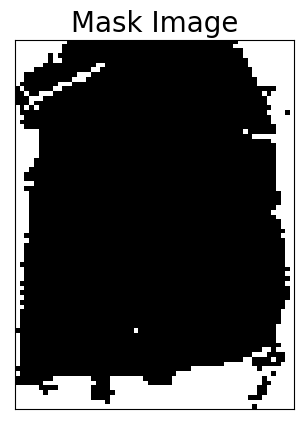

In [5]:
adata = po.CreateMaskImage(adata, scale_factor=1)

# Step2：Pattern Recognition

In [6]:
Patterndict = dict(L1 = ['RELN','CXCL14'],
                   L2 = ['HPCAL1', 'C1QL2','CARTPT', 'PENK'],
                   L3 = ['NEFH', 'FREM3','SNCG','LGALS1'],
                   L4 = ['NEFH','RORB', 'VAMP1'],
                   L5 = ['TMSB10', 'PCP4', 'TRABD2A', 'CAMK2D'],
                   L6 = ['KRT17', 'NR4A2', 'SYNPR'],
                   WM = ['MOBP', 'MBP', 'PLP1', 'TF', 'CRYAB', 'CNP'])

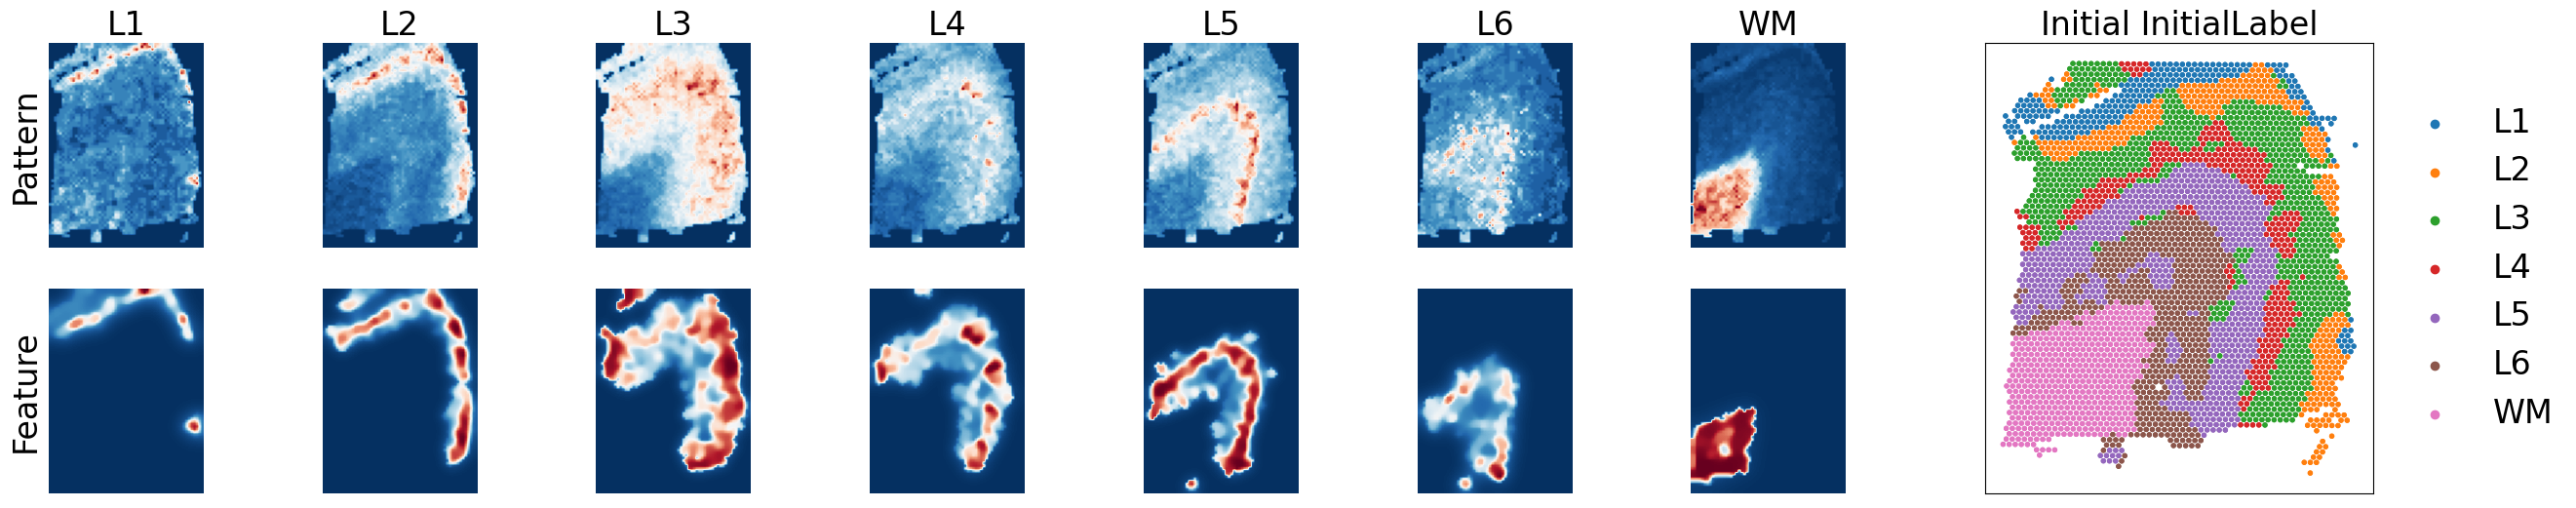

In [7]:
adata = po.SpatialPatternRecognition(adata, Patterndict=Patterndict,
                                     small_objects=1, dilation_radius=1,
                                     denoise_weight=0.1)

# Step3：Priori Initialization

---Create Spatial Graph: Done!
---Compute Spatial Energy: Done!
---Find K-Nearest Neighbor in UMAP: Done!
---Compute KNN Energy: Done!
---Compute Global Energy: Done!
Elapsed time: 20.664s


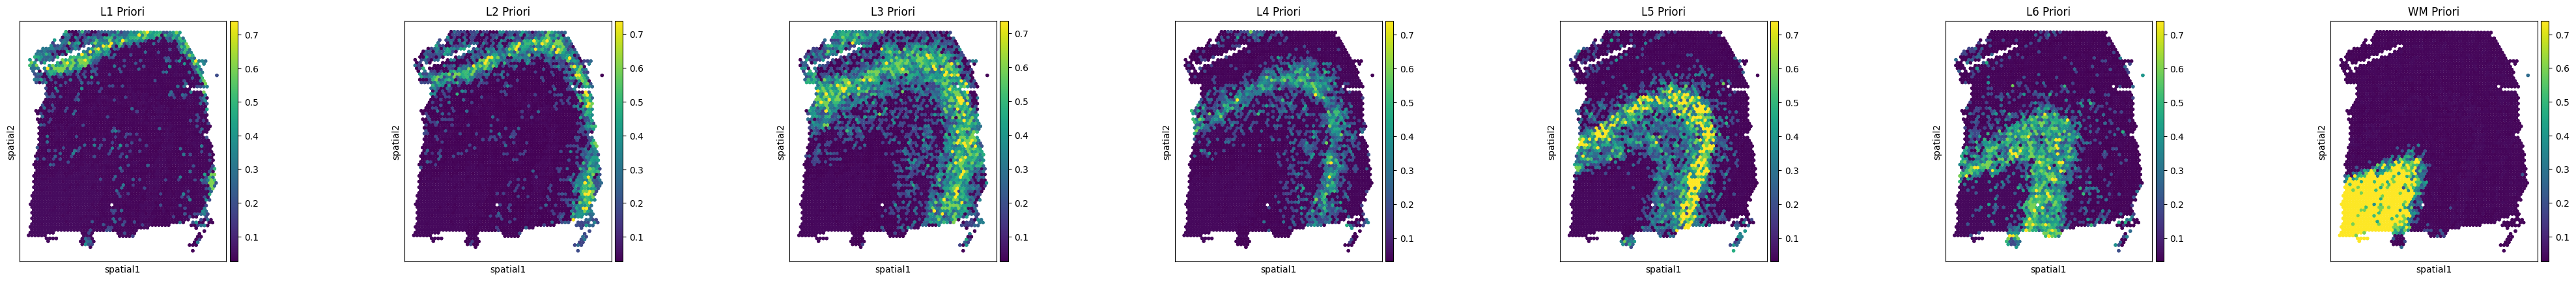

In [8]:
adata = po.PrioriInitialization(adata, label_key='InitialLabel',
                                omegaK=0.99, omegaG=0.01)

# Step4：Posteriori Inference

log-likelihood: -205102.1927950005
Elapsed time: 46.581s


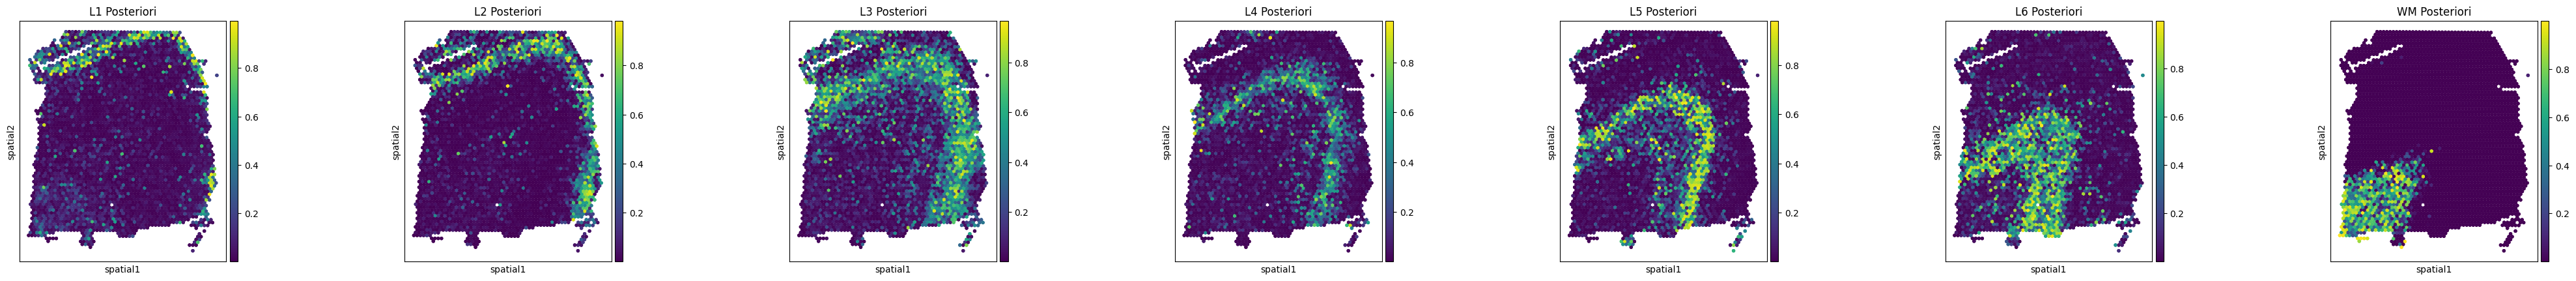

In [9]:
adata = po.PosterioriInference(adata, label_key='InitialLabel')

# Step5：Label Renew

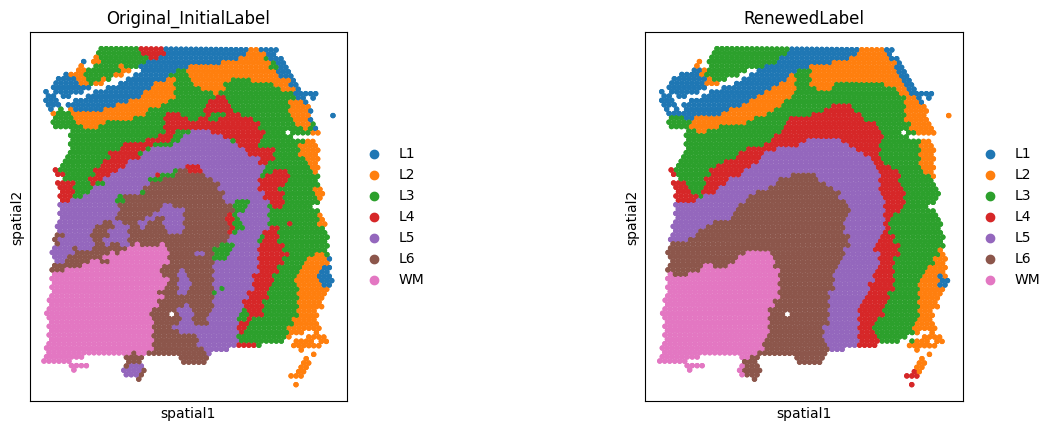

In [10]:
adata = po.LabelRenew(adata, method='imgbased', keep_region=None, 
                      raw_key='InitialLabel', new_key='RenewedLabel')

In [11]:
adata

AnnData object with n_obs × n_vars = 3673 × 14711
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'SizeFactor', 'spotID', 'InitialLabel', 'InitialLabel_Skeleton', 'L1 Priori', 'L2 Priori', 'L3 Priori', 'L4 Priori', 'L5 Priori', 'L6 Priori', 'WM Priori', 'L1 Posteriori', 'L2 Posteriori', 'L3 Posteriori', 'L4 Posteriori', 'L5 Posteriori', 'L6 Posteriori', 'WM Posteriori', 'RenewedLabel'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial', 'Mask', 'PatternList', 'unknown_type', 'PatternImage', 'FeatureImage', 'InitialLabel_colors', 'spatial_neighbors', 'InitialLabel_PriorImage', 'InitialLabel_Energy', 'InitialLabel_PosteriorImage', 'Original_InitialLabel_colors', 'RenewedLabel_colors'
    obsm: 'spatial'
    layers: 'RawX', 'DenoisedX'
    obsp: 'spatial_connectivities', 'spatial_distances', 'knn_connectivities'